In [24]:
import numpy as np
import matplotlib.pyplot as plt
import random
import math
import networkx as nx
from monte_carlo_sdp import *


def run_mcmc_diagnostics_v2(bn, target, target_value, patient, threshold,
                             n_iterations=100000, n_chains=4,
                             use_lw_seed=True):
    """
    Runs MCMC diagnostics for the NumPy-vectorised fast_mcmc_sdp_estimation.

    Uses the same integer-indexed inner loop as the production MCMC,
    so the diagnostics reflect the actual chain behaviour.

    Produces three plots:
      1. Trace plot  — running decision fraction per chain (burn-in)
      2. ACF         — autocorrelation of decision indicator (thinning)
      3. R-hat       — Gelman-Rubin convergence over time

    Parameters
    ----------
    use_lw_seed : bool
        If True, seeds via fast ancestral sampling (same as production).
        If False, uses pure random init (for comparison).
    """
    hidden_vars       = [n for n in bn.nodes() if n not in patient and n != target]
    target_states_list = bn.get_cpds(target).state_names[target]
    n_target_states   = len(target_states_list)
    target_state_idx  = list(range(n_target_states))

    # ── Build integer-indexed CPD tables (same as production MCMC) ───────────
    all_nodes   = list(bn.nodes())
    state_index = {}
    for n in all_nodes:
        cpd = bn.get_cpds(n)
        state_index[n] = {s: i for i, s in enumerate(cpd.state_names[n])}

    cpd_array = {}
    cpd_vars  = {}
    for n in all_nodes:
        cpd = bn.get_cpds(n)
        arr = np.asarray(cpd.values, dtype=float)
        arr[arr == 0.0] = 1e-10
        arr = arr / arr.sum(axis=0, keepdims=True)
        cpd_array[n] = arr
        cpd_vars[n]  = list(cpd.variables)

    children_cache = {v: list(bn.get_children(v)) for v in hidden_vars}
    affected_cache = {v: [v] + children_cache[v] for v in hidden_vars}

    inv_state = {v: {i: s for s, i in state_index[v].items()} for v in bn.nodes()}

    # Patient integer lookup
    patient_idx = {v: state_index[v][val] for v, val in patient.items()}

    # ── Helpers ───────────────────────────────────────────────────────────────
    def full_log_joint(state_idx_dict, t_idx):
        lp = 0.0
        for node in all_nodes:
            idx = tuple(
                t_idx if v == target else state_idx_dict[v]
                for v in cpd_vars[node]
            )
            p = cpd_array[node][idx]
            if p == 0.0:
                return float('-inf')
            lp += math.log(p)
        return lp

    def log_sum(values):
        finite = [v for v in values if v != float('-inf')]
        if not finite:
            return float('-inf')
        m = max(finite)
        return m + math.log(sum(math.exp(v - m) for v in finite))

    def get_seed(use_lw):
        idx = dict(patient_idx)
        if use_lw:
            try:
                topo_order = list(nx.topological_sort(bn))
                sample = dict(patient)
                for node in topo_order:
                    if node in sample or node == target or node not in hidden_vars:
                        continue
                    cpd     = bn.get_cpds(node)
                    parents = cpd.variables[1:]
                    if not parents:
                        probs = cpd_array[node].flatten()
                    else:
                        parent_idx_tuple = tuple(
                            state_index[p][sample[p]] if p in sample else 0
                            for p in parents
                        )
                        probs = cpd_array[node][(slice(None),) + parent_idx_tuple]
                    probs = np.array(probs, dtype=float)
                    probs = np.maximum(probs, 0)
                    total = probs.sum()
                    probs = probs / total if total > 0 else np.ones(len(probs)) / len(probs)
                    sampled = np.random.choice(len(probs), p=probs)
                    sample[node]   = inv_state[node][sampled]
                    idx[node]      = sampled
            except Exception as e:
                print(f"    [SEED] Ancestral seed failed ({e}) — random fallback")
                for v in hidden_vars:
                    idx[v] = random.randrange(cpd_array[v].shape[0])
        else:
            for v in hidden_vars:
                idx[v] = random.randrange(cpd_array[v].shape[0])
        return idx

    def run_chain(chain_idx):
        print(f"  Chain {chain_idx + 1}/{n_chains}...")
        current_idx   = get_seed(use_lw_seed)
        current_lj    = [full_log_joint(current_idx, t) for t in target_state_idx]
        current_log_p = log_sum(current_lj)
        print("CURRENT LOG P ")
        print(current_log_p)

        decisions = []

        for i in range(n_iterations):
            var = random.choice(hidden_vars)
            cur_val    = current_idx[var]
            cardinality = cpd_array[var].shape[0]
            if cardinality < 2:
                pass
            else:
                new_val = random.randrange(cardinality - 1)
                if new_val >= cur_val:
                    new_val += 1

                proposed_lj = [0.0] * n_target_states
                recompute   = False

                for t_idx in target_state_idx:
                    if current_lj[t_idx] == float('-inf'):
                        recompute = True
                        break
                    delta  = 0.0
                    failed = False
                    for node in affected_cache[var]:
                        order = cpd_vars[node]
                        p_old_args = tuple(
                            t_idx if v == target else current_idx[v]
                            for v in order
                        )
                        p_new_args = tuple(
                            t_idx if v == target
                            else (new_val if v == var else current_idx[v])
                            for v in order
                        )
                        p_old = cpd_array[node][p_old_args]
                        p_new = cpd_array[node][p_new_args]
                        if p_new == 0.0:
                            failed = True; break
                        if p_old == 0.0:
                            recompute = True; break
                        delta += math.log(p_new) - math.log(p_old)
                    if recompute:
                        break
                    if failed:
                        proposed_lj[t_idx] = float('-inf')
                        continue
                    proposed_lj[t_idx] = current_lj[t_idx] + delta

                if recompute:
                    tmp = dict(current_idx)
                    tmp[var]     = new_val
                    proposed_lj  = [full_log_joint(tmp, t) for t in target_state_idx]

                proposed_log_p = log_sum(proposed_lj)
                log_alpha      = proposed_log_p - current_log_p

                if log_alpha >= 0 or (
                    proposed_log_p != float('-inf')
                    and math.log(random.random()) < log_alpha
                ):
                    current_idx[var] = new_val
                    current_lj       = proposed_lj
                    current_log_p    = proposed_log_p

            # Record decision at every iteration
            sample_h = {v: inv_state[v][current_idx[v]] for v in hidden_vars}
            full_ev  = {**patient, **sample_h}
            p_target = get_exact_target_posterior_O1(bn, target, target_value, full_ev)
            decisions.append(1 if p_target >= threshold else 0)

        return decisions

    # ── Run all chains ────────────────────────────────────────────────────────
    all_chains = np.array([run_chain(c) for c in range(n_chains)], dtype=float)

    # ── Plot 1: Trace plot (running mean) ─────────────────────────────────────
    running_means = np.cumsum(all_chains, axis=1) / np.arange(1, n_iterations + 1)

    fig, axes = plt.subplots(3, 1, figsize=(13, 13))
    seed_label = "ancestral seed" if use_lw_seed else "random seed"

    ax = axes[0]
    for c in range(n_chains):
        ax.plot(running_means[c], alpha=0.7, label=f'Chain {c+1}')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Running mean of decision indicator')
    ax.set_title(f'Trace plot — {bn.name} ({seed_label})\n'
                 f'burn-in = iteration where all chains stabilise')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # ── Plot 2: ACF ───────────────────────────────────────────────────────────
    MAX_LAG     = 1000
    signal      = all_chains[0] - all_chains[0].mean()
    acf_raw     = np.correlate(signal, signal, mode='full')
    acf_raw     = acf_raw[len(acf_raw) // 2:]
    acf_vals    = acf_raw / acf_raw[0]
    significance = 1.96 / math.sqrt(n_iterations)

    ax = axes[1]
    ax.bar(np.arange(MAX_LAG), acf_vals[:MAX_LAG], color='steelblue', alpha=0.7)
    ax.axhline( significance, color='red', ls='--', label='95% significance band')
    ax.axhline(-significance, color='red', ls='--')
    ax.set_xlabel('Lag')
    ax.set_ylabel('Autocorrelation')
    ax.set_title(f'ACF — chain 1\n'
                 f'thinning = smallest lag where ACF enters the red band')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # ── Plot 3: Gelman-Rubin R-hat ────────────────────────────────────────────
    rhat_values  = []
    check_points = list(range(100, n_iterations, max(100, n_iterations // 500)))

    for t in check_points:
        chains_t     = all_chains[:, :t]
        n, m         = chains_t.shape[1], n_chains
        chain_means  = chains_t.mean(axis=1)
        grand_mean   = chain_means.mean()
        B            = n / (m - 1) * np.sum((chain_means - grand_mean) ** 2)
        W            = np.mean(np.var(chains_t, axis=1, ddof=1))
        var_hat      = (1 - 1/n) * W + B / n
        rhat         = math.sqrt(var_hat / W) if W > 0 else float('nan')
        rhat_values.append(rhat)

    ax = axes[2]
    ax.plot(check_points, rhat_values, color='darkgreen', lw=1.5)
    ax.axhline(1.1, color='red',  ls='--', label='R-hat=1.1 (warning)')
    ax.axhline(1.0, color='gray', ls=':')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Gelman-Rubin R-hat')
    ax.set_title('R-hat convergence\n(should drop and stay below 1.1)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    plt.suptitle(f'MCMC Diagnostics v2 — {bn.name}  [{seed_label}]',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    #plt.savefig(f'mcmc_diagnostics_{bn.name.replace(" ", "_")}.png',
    #            dpi=130, bbox_inches='tight')
    plt.show()

    # ── Suggested parameters ──────────────────────────────────────────────────
    final_means = running_means[:, -1]
    stable      = np.all(np.abs(running_means - final_means[:, None]) < 0.05, axis=0)
    suggested_burnin   = int(np.argmax(stable)) if stable.any() else n_iterations // 2

    below = np.where(np.abs(acf_vals[1:MAX_LAG]) < significance)[0]
    suggested_thinning = int(below[0]) + 1 if len(below) > 0 else MAX_LAG

    final_rhat = rhat_values[-1]
    print(f"\n{'='*55}")
    print(f"Network      : {bn.name}")
    print(f"Seed         : {seed_label}")
    print(f"Hidden vars  : {len(hidden_vars)}")
    print(f"Suggested burn-in  : {suggested_burnin}")
    print(f"Suggested thinning : {suggested_thinning}")
    print(f"Final R-hat        : {final_rhat:.4f}  "
          f"{'✓ converged' if final_rhat < 1.1 else '✗ NOT converged'}")
    print(f"{'='*55}\n")

    return {
        'burn_in':   suggested_burnin,
        'thinning':  suggested_thinning,
        'rhat':      final_rhat,
        'chains':    all_chains,
    }

In [28]:
"""
cpt_bimodality_experiment.py
────────────────────────────
Holds Win95pts topology fixed and re-samples all CPTs under each of the
9 CPDParam regimes.  For every regime it runs run_mcmc_diagnostics_v2 and
records:
  - final R-hat
  - spread of per-chain final means 
  - per-chain final means
  - the diagnostic figure

The key question:

  If bimodality is purely topological it will appear across ALL regimes.
  If it is CPT-driven it will disappear once CPTs are softened.
"""

import copy
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pgmpy.utils import get_example_model
from pgmpy.factors.discrete import TabularCPD


def select_optimal_target_node(bn):
    """
    Selects a target node deeply embedded in the network (highest degree).
    Highly connected nodes provide a smooth, responsive probability gradient 
    for the Hill Climber, making extreme SDP values (0.90+) reachable.
    """
    best_node = None
    max_degree = -1
    
    for node in bn.nodes():
        # Ensure it's a binary node
        if len(bn.get_cpds(node).state_names[node]) != 2:
            continue
            
        degree = len(bn.get_parents(node)) + len(bn.get_children(node))
        if degree > max_degree:
            max_degree = degree
            best_node = node
            
    # Fallback if no binary nodes exist (rare)
    if best_node is None:
        return random.choice(list(bn.nodes()))
        
    return best_node

from dataclasses import dataclass
@dataclass(frozen=True)
class CPDParam:
    """
    A single (alpha, beta) configuration for CPD sampling.
 
    alpha, beta : Beta distribution parameters.
    label       : Short identifier used in filenames.
    description : Human-readable explanation of the regime.
    """
    alpha: float
    beta: float
    label: str
    description: str
 
from typing import List
# Nine configurations covering the rigidity × bias space.
CPD_PARAMS: List[CPDParam] = [
    # ── Symmetric (unbiased, mean(p) = 0.5) ──────────────────
    CPDParam(0.2,  0.2,  "rigid_extreme",       "Bimodal: CPDs overwhelmingly near 0 or 1"),
    CPDParam(0.5,  0.5,  "rigid_moderate",      "U-shaped: CPDs skewed toward extremes"),
    CPDParam(1.0,  1.0,  "uniform",             "Uniform: all CPD values equally likely"),
    CPDParam(3.0,  3.0,  "uncertain_moderate",      "Bell-shaped: CPDs concentrated near 0.5"),
    CPDParam(10.0, 10.0, "uncertain_strong",        "Tightly concentrated near 0.5"),

    # ── Asymmetric: biased toward 0 ───────────────────────────
    # Beta(0.5, 2.0): spread across [0,1] but pulled toward 0
    CPDParam(0.5,  2.0,  "spread_bias_low",     "Spread + biased low: mean(p) ≈ 0.20, some variance"),
    # Beta(1.0, 5.0): concentrated near 0 — deterministic in the low direction
    CPDParam(1.0,  5.0,  "concentrated_bias_low","Concentrated near 0: mean(p) ≈ 0.17, low variance"),

    # ── Asymmetric: biased toward 1 ───────────────────────────
    # Beta(2.0, 0.5): spread across [0,1] but pulled toward 1
    CPDParam(2.0,  0.5,  "spread_bias_high",    "Spread + biased high: mean(p) ≈ 0.80, some variance"),
    # Beta(5.0, 1.0): concentrated near 1 — deterministic in the high direction
    CPDParam(5.0,  1.0,  "concentrated_bias_high","Concentrated near 1: mean(p) ≈ 0.83, low variance"),
]


# ── Helpers ───────────────────────────────────────────────────────────────────

def resample_cpds(bn_original, alpha: float, beta: float, rng: np.random.Generator):
    bn = copy.deepcopy(bn_original)

    for node in bn.nodes():
        original_cpd  = bn_original.get_cpds(node)
        variable_card = original_cpd.variable_card
        parents       = original_cpd.variables[1:]        # list of parent names
        evidence_card = [bn_original.get_cpds(p).variable_card for p in parents]
        n_parent_configs = int(np.prod(evidence_card)) if evidence_card else 1

        # Build state_names dict explicitly from each variable's own CPD
        all_vars = [node] + list(parents)
        state_names = {
            v: bn_original.get_cpds(v).state_names[v]
            for v in all_vars
        }

        values = np.zeros((variable_card, n_parent_configs))
        for col in range(n_parent_configs):
            if variable_card == 2:
                p1 = float(rng.beta(alpha, beta))
                values[:, col] = [1.0 - p1, p1]
            else:
                draw = rng.gamma(alpha, 1.0, size=variable_card)
                draw = draw / draw.sum()
                values[:, col] = draw

        new_cpd = TabularCPD(
            variable=node,
            variable_card=variable_card,
            values=values,
            evidence=list(parents) if parents else None,
            evidence_card=evidence_card if evidence_card else None,
            state_names=state_names,
        )
        bn.add_cpds(new_cpd)

    assert bn.check_model(), "Model validation failed after CPD resample."
    return bn


def summarise_chains(chains: np.ndarray):
    """
    chains : (n_chains, n_iterations) float array of decision indicators.
    Returns dict with final means, spread, and crude bimodality flag.
    """
    running = np.cumsum(chains, axis=1) / np.arange(1, chains.shape[1] + 1)
    finals  = running[:, -1]
    delta   = finals.max() - finals.min()
    return {
        'final_means':  finals,
        'delta_final':  delta,
        'bimodal_flag': delta >= 0.10,
    }


# ── Main experiment ───────────────────────────────────────────────────────────

def run_cpt_bimodality_experiment(
    interesting_patient: dict,
    target: str,
    target_value: str,
    threshold: float = 0.5,
    n_iterations: int = 15_000,
    n_chains: int = 4,
    n_seeds: int = 3,           # independent CPD resamples per regime
    output_dir: str = "cpt_bimodality_results",
    use_lw_seed: bool = True,
):
    """
    Parameters
    ----------
    interesting_patient : dict
        The evidence dict whose bimodality we are studying.
    target, target_value : str
        As used in the MCMC diagnostics.
    n_seeds : int
        Number of independent CPD resamples per regime.  Using > 1 controls
        for variance introduced by a single unlucky draw.
    output_dir : str
        Directory for per-regime diagnostic figures and the summary CSV.
    """
    os.makedirs(output_dir, exist_ok=True)

    win95pts_base = get_example_model('win95pts')

    rows = []

    # ── Summary figure ────────────────────────────────────────────────────────
    n_regimes  = len(CPD_PARAMS)
    fig_sum, axes_sum = plt.subplots(
        n_regimes, n_seeds,
        figsize=(4.5 * n_seeds, 3.0 * n_regimes),
        squeeze=False,
    )
    fig_sum.suptitle(
        'Win95pts — Δ(final means) per CPD regime and seed\n'
        'Each subplot: running means of 4 chains.  '
        'Spread ≥ 0.10 = bimodality flag.',
        fontsize=11, fontweight='bold', y=1.002,
    )

    for regime_idx, cpd_param in enumerate(CPD_PARAMS):
        print(f"\n{'='*65}")
        print(f"Regime {regime_idx+1}/{n_regimes}: {cpd_param.label}")
        print(f"  α={cpd_param.alpha}, β={cpd_param.beta} — {cpd_param.description}")
        print(f"{'='*65}")

        for seed_idx in range(n_seeds):
            rng   = np.random.default_rng(seed=42 + seed_idx * 100 + regime_idx)
            label = f"{cpd_param.label}_seed{seed_idx}"
            print(f"  Seed {seed_idx+1}/{n_seeds} …", end=' ', flush=True)

            # ── Resample CPDs ─────────────────────────────────────────────────
            if cpd_param.label == 'original':
                bn = copy.deepcopy(win95pts_base)
            else:
                bn = resample_cpds(win95pts_base, cpd_param.alpha, cpd_param.beta, rng)
            bn.name = f"win95pts_{label}"

            # ── Run MCMC diagnostics (suppress figure save; we handle it) ─────
            diag = run_mcmc_diagnostics_v2(
                bn, target, target_value, interesting_patient, threshold,
                n_iterations=n_iterations,
                n_chains=n_chains,
                use_lw_seed=use_lw_seed,
            )

            # ── Extract summary stats ─────────────────────────────────────────
            summary = summarise_chains(diag['chains'])
            print(
                f"Δ_final={summary['delta_final']:.3f}  "
                f"R-hat={diag['rhat']:.3f}  "
                f"{'⚠ BIMODAL' if summary['bimodal_flag'] else '✓ ok'}"
            )

            # ── Fill summary grid subplot ─────────────────────────────────────
            ax = axes_sum[regime_idx, seed_idx]
            running = (np.cumsum(diag['chains'], axis=1)
                       / np.arange(1, n_iterations + 1))
            PALETTE = ['#C0392B', '#E67E22', '#7D3C98', '#1A5276',
                       '#117A65', '#B7950B']
            for c in range(n_chains):
                ax.plot(running[c], lw=0.8, alpha=0.85,
                        color=PALETTE[c % len(PALETTE)])

            delta     = summary['delta_final']
            flag_col  = '#8B0000' if summary['bimodal_flag'] else '#1B5E20'
            ax.set_ylim(-0.05, 1.10)
            ax.set_xlim(0, n_iterations)
            ax.tick_params(labelsize=5.5)
            ax.grid(True, alpha=0.2, lw=0.3)
            ax.spines[['top', 'right']].set_visible(False)

            title_top = (f"{cpd_param.label}" if seed_idx == 0
                         else f"seed {seed_idx+1}")
            ax.set_title(title_top, fontsize=6.5, fontweight='bold',
                         loc='left', pad=2)
            ax.annotate(
                f"Δ={delta:.3f}  R={diag['rhat']:.2f}",
                xy=(0.97, 0.06), xycoords='axes fraction',
                ha='right', va='bottom', fontsize=5.5,
                color=flag_col,
                bbox=dict(boxstyle='round,pad=0.2',
                          fc='#FDF2F2' if summary['bimodal_flag'] else '#F1FBF4',
                          ec=flag_col, lw=0.5, alpha=0.85),
            )
            if regime_idx == n_regimes - 1:
                ax.set_xlabel('Iteration', fontsize=6)
            if seed_idx == 0:
                ax.set_ylabel(cpd_param.label[:18], fontsize=5.5, rotation=90,
                              labelpad=2)

            # ── Record row ────────────────────────────────────────────────────
            row = {
                'regime':       cpd_param.label,
                'description':  cpd_param.description,
                'alpha':        cpd_param.alpha,
                'beta':         cpd_param.beta,
                'seed':         seed_idx,
                'rhat':         diag['rhat'],
                'delta_final':  delta,
                'bimodal_flag': summary['bimodal_flag'],
                'suggested_burnin':   diag['burn_in'],
                'suggested_thinning': diag['thinning'],
            }
            for c, m in enumerate(summary['final_means']):
                row[f'chain{c+1}_final'] = round(float(m), 4)
            rows.append(row)

        # ── Per-regime figure already saved by run_mcmc_diagnostics_v2 ───────
        # The function auto-saves to mcmc_diagnostics_{bn.name}.png;
        # move the last seed's figure to output_dir for safe-keeping.
        src = f"mcmc_diagnostics_{bn.name.replace(' ', '_')}.png"
        if os.path.exists(src):
            os.rename(src, os.path.join(output_dir, os.path.basename(src)))

    # ── Save summary grid ─────────────────────────────────────────────────────
    fig_sum.tight_layout()
    grid_path = os.path.join(output_dir, "summary_grid.png")
    fig_sum.savefig(grid_path, dpi=150, bbox_inches='tight')
    plt.close(fig_sum)
    print(f"\nSummary grid saved → {grid_path}")

    # ── Save CSV ──────────────────────────────────────────────────────────────
    df = pd.DataFrame(rows)
    csv_path = os.path.join(output_dir, "cpt_bimodality_results.csv")
    df.to_csv(csv_path, index=False)
    print(f"Results CSV saved → {csv_path}")

    # ── Print condensed table ─────────────────────────────────────────────────
    print(f"\n{'='*65}")
    print("SUMMARY — mean Δ_final and bimodality rate per regime")
    print(f"{'='*65}")
    print(f"{'Regime':<26} {'α':>5} {'β':>5}  "
          f"{'mean Δ':>7}  {'max Δ':>6}  {'bimodal':>8}")
    print('-' * 65)
    for _, grp in df.groupby('regime', sort=False):
        r = grp.iloc[0]
        bimodal_rate = grp['bimodal_flag'].mean()
        print(
            f"  {r['regime']:<24} {r['alpha']:>5.1f} {r['beta']:>5.1f}  "
            f"{grp['delta_final'].mean():>7.3f}  "
            f"{grp['delta_final'].max():>6.3f}  "
            f"  {bimodal_rate*100:>5.0f}%"
        )
    print(f"{'='*65}")

    return df





Regime 1/11: original
  α=0.0, β=0.0 — Original Win95pts CPDs (unchanged)
  Seed 1/1 …   Chain 1/4...
CURRENT LOG P 
-132.74914283134984
  Chain 2/4...
CURRENT LOG P 
-147.08004273017616
  Chain 3/4...
CURRENT LOG P 
-148.81464378556427
  Chain 4/4...
CURRENT LOG P 
-171.28966578793526


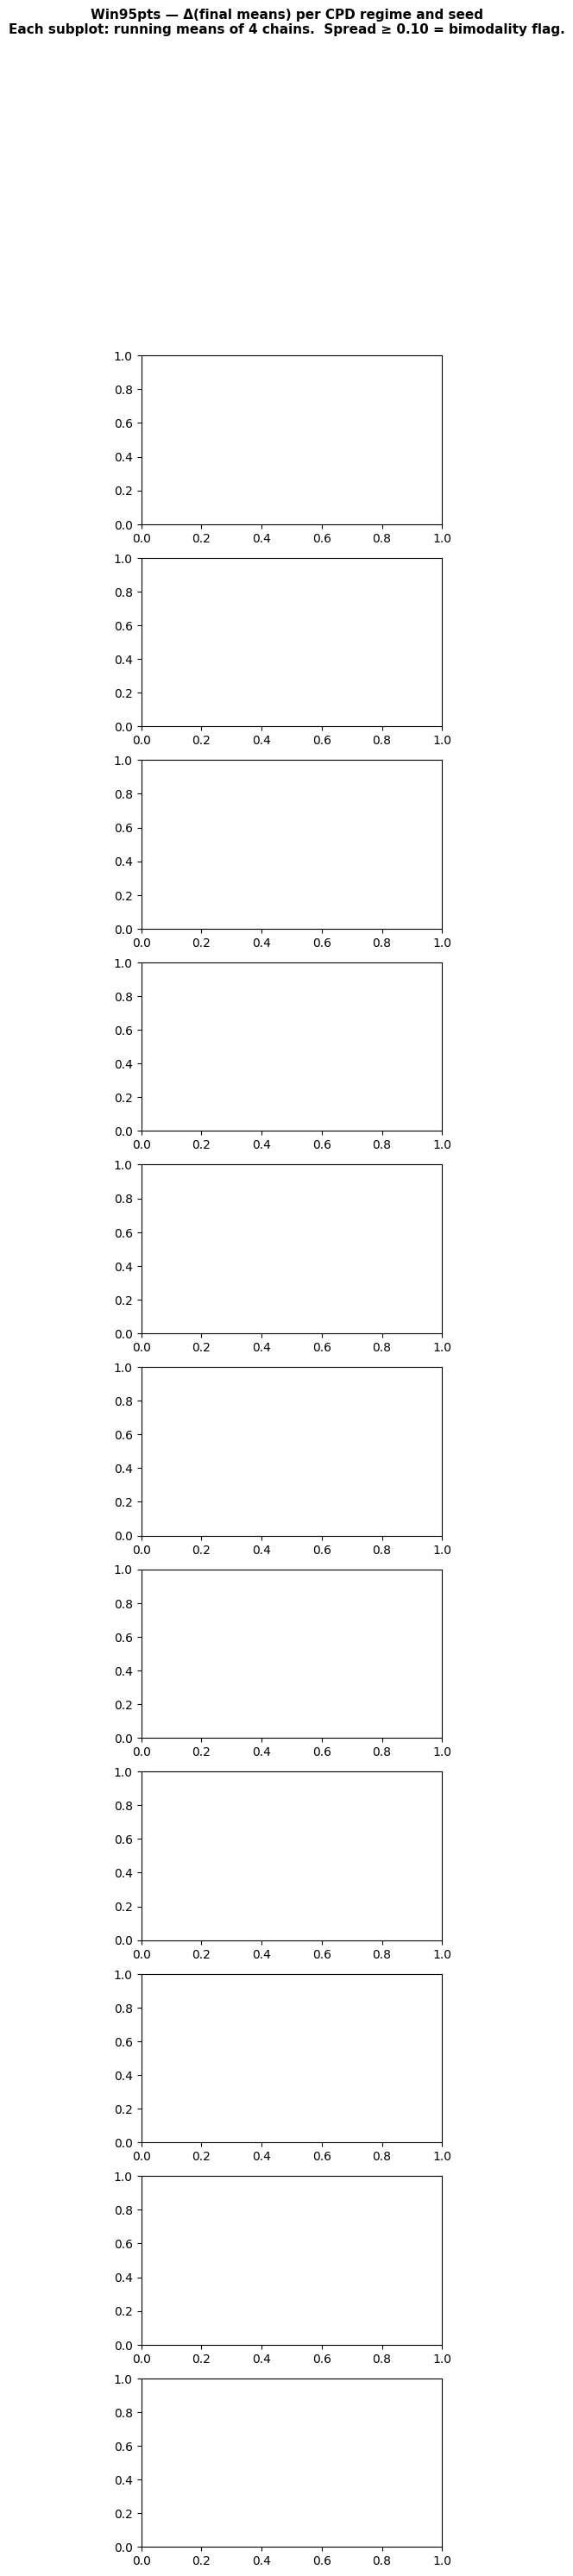

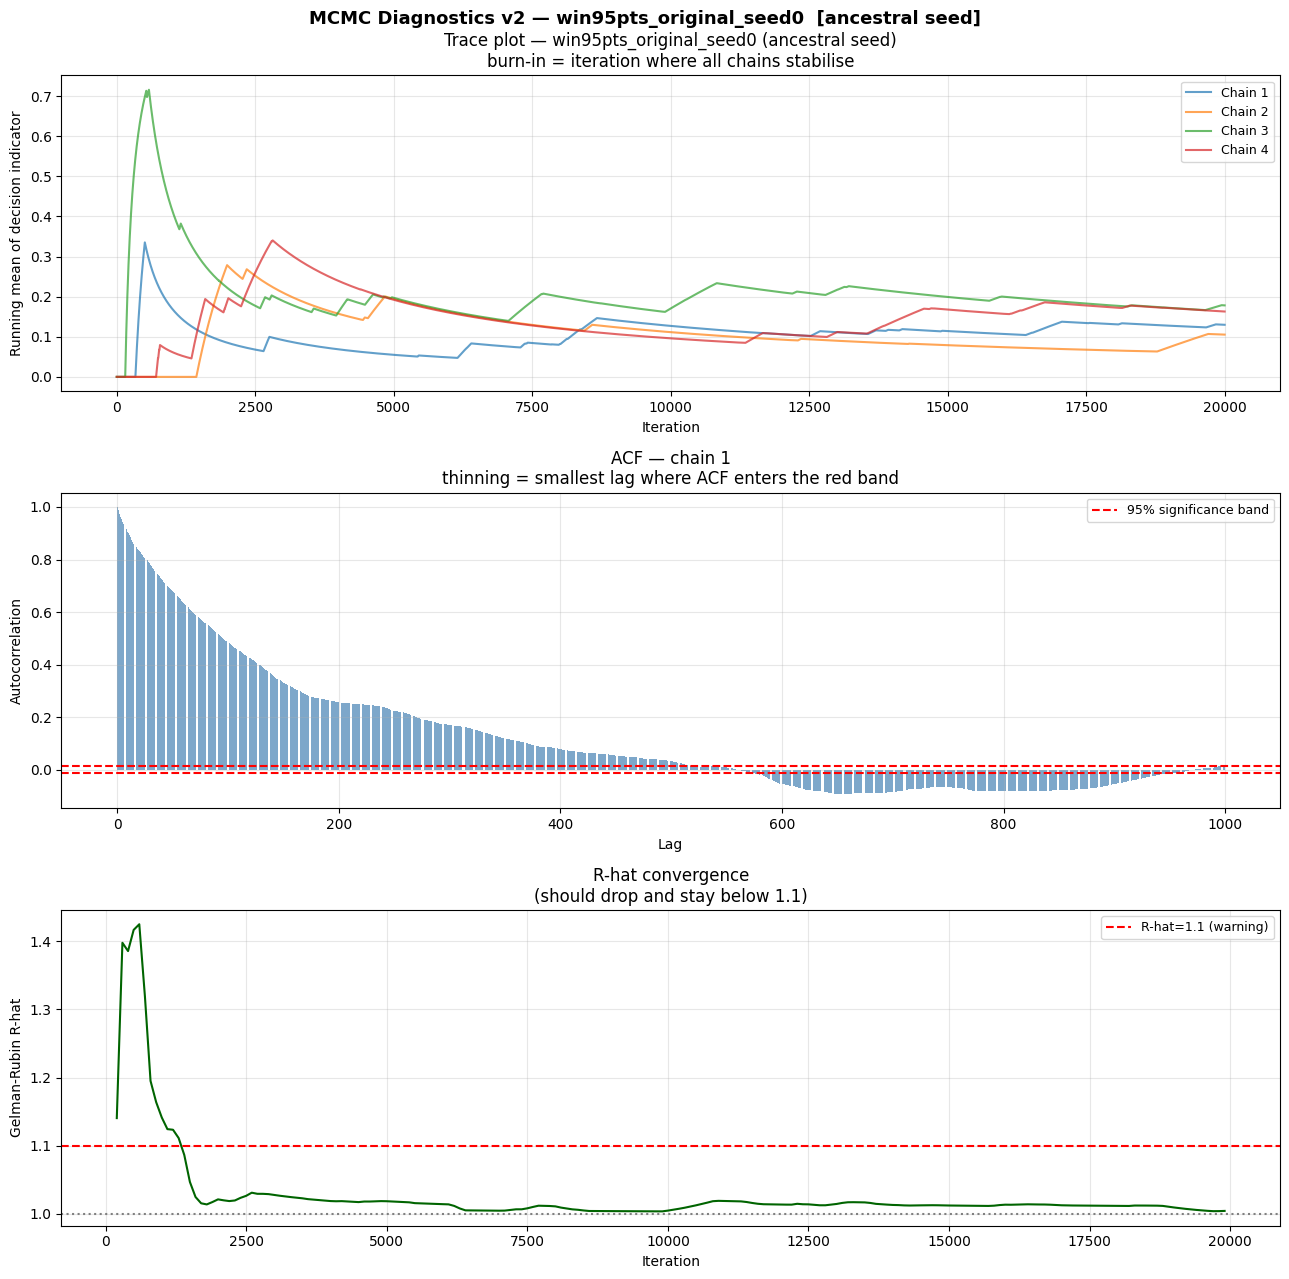


Network      : win95pts_original_seed0
Seed         : ancestral seed
Hidden vars  : 37
Suggested burn-in  : 6374
Suggested thinning : 519
Final R-hat        : 1.0042  ✓ converged

Δ_final=0.073  R-hat=1.004  ✓ ok

Regime 2/11: original
  α=0.0, β=0.0 — Original Win95pts CPDs (unchanged)
  Seed 1/1 …   Chain 1/4...
CURRENT LOG P 
-147.08004273017616
  Chain 2/4...
CURRENT LOG P 
-171.28966578793526
  Chain 3/4...
CURRENT LOG P 
-176.49000274602307
  Chain 4/4...
CURRENT LOG P 
-148.46633709129605


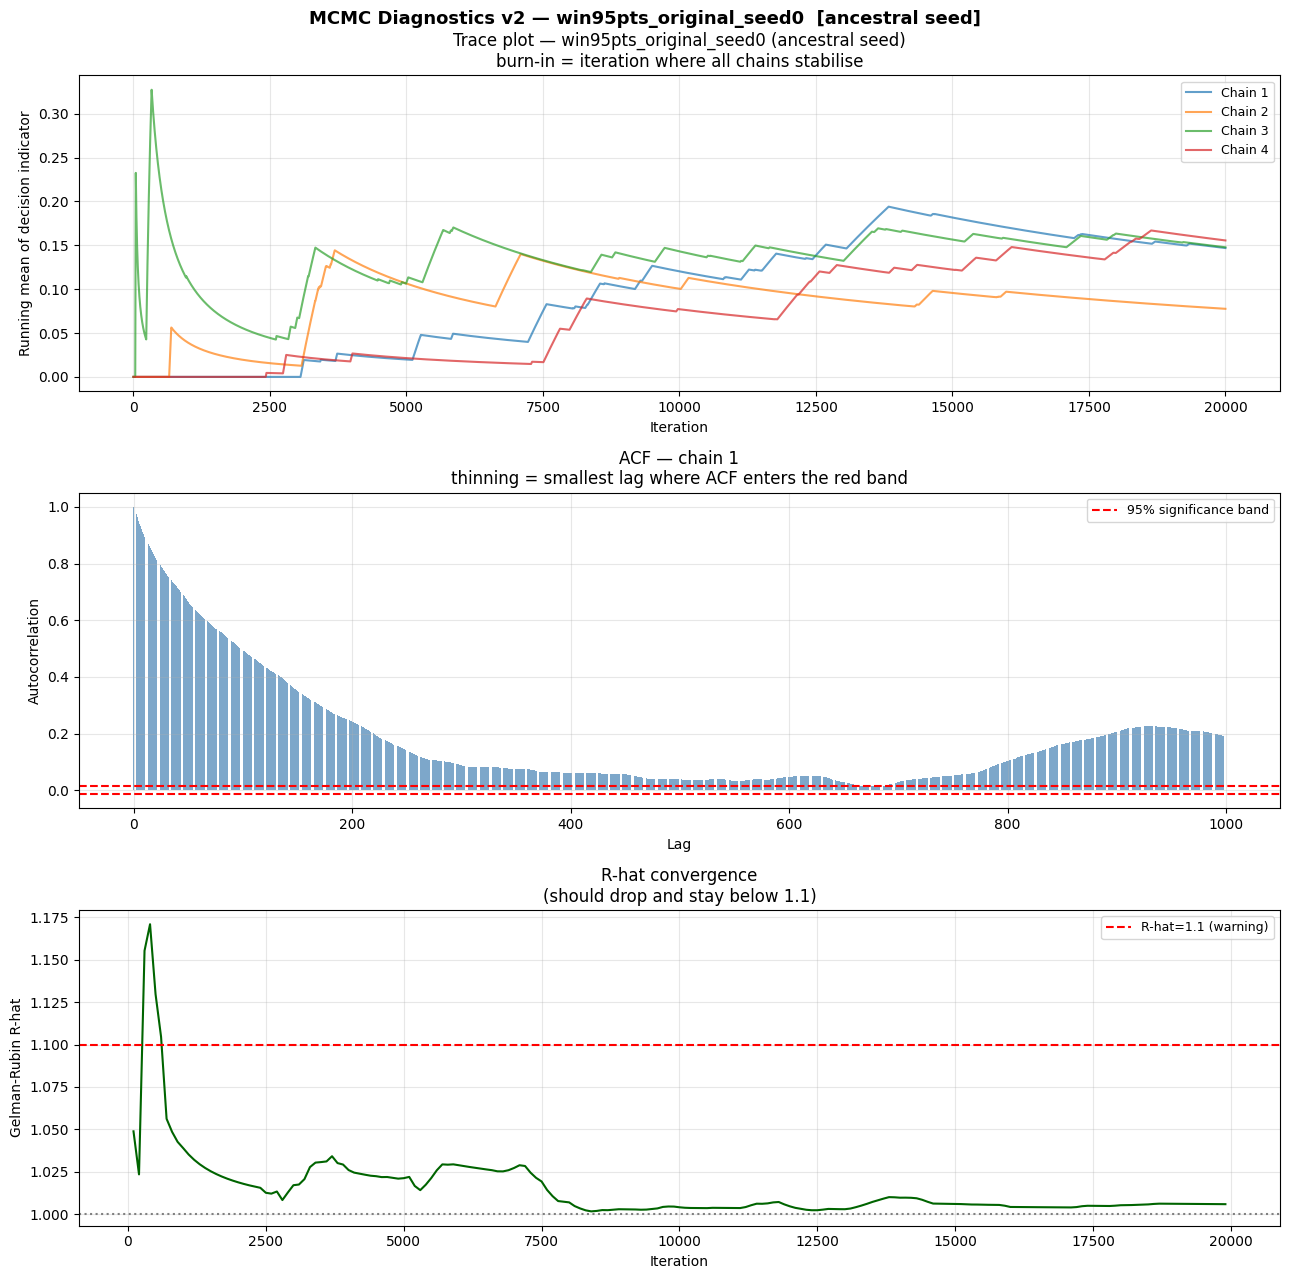


Network      : win95pts_original_seed0
Seed         : ancestral seed
Hidden vars  : 37
Suggested burn-in  : 12341
Suggested thinning : 669
Final R-hat        : 1.0058  ✓ converged

Δ_final=0.078  R-hat=1.006  ✓ ok

Regime 3/11: rigid_extreme
  α=0.2, β=0.2 — Bimodal: CPDs overwhelmingly near 0 or 1
  Seed 1/1 …   Chain 1/4...
CURRENT LOG P 
-109.6654642840006
  Chain 2/4...
CURRENT LOG P 
-120.83787586788121
  Chain 3/4...
CURRENT LOG P 
-113.07187487505881
  Chain 4/4...
CURRENT LOG P 
-122.0092990970605


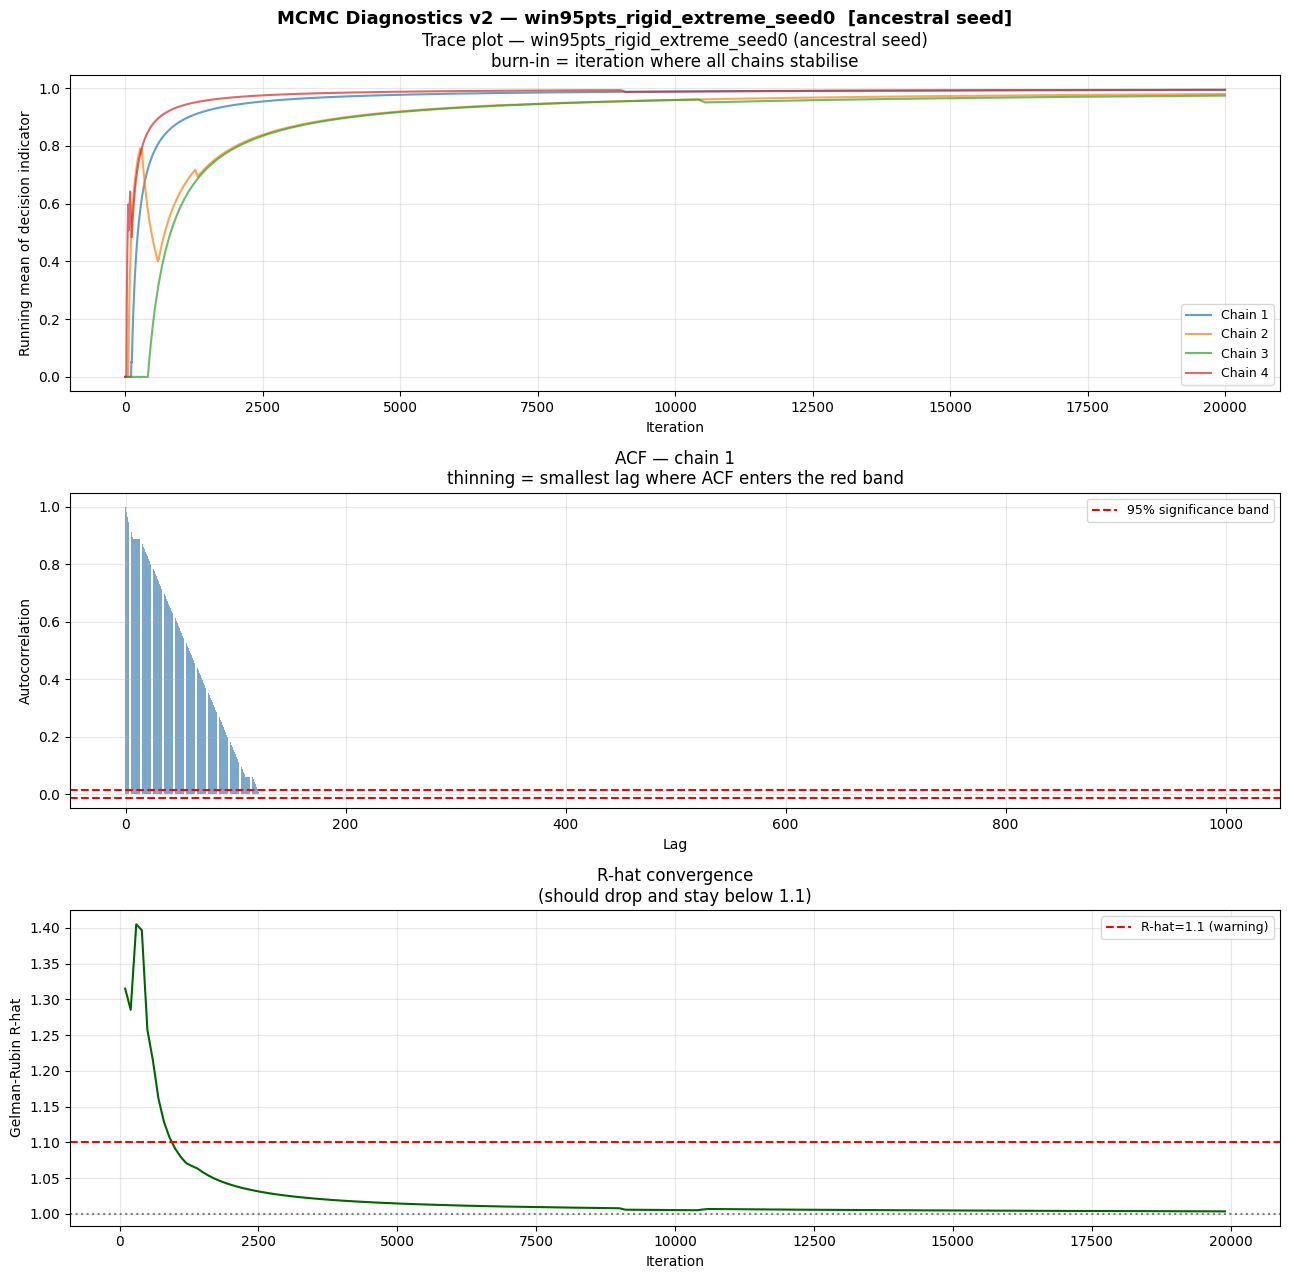


Network      : win95pts_rigid_extreme_seed0
Seed         : ancestral seed
Hidden vars  : 37
Suggested burn-in  : 5730
Suggested thinning : 121
Final R-hat        : 1.0037  ✓ converged

Δ_final=0.020  R-hat=1.004  ✓ ok

Regime 4/11: rigid_moderate
  α=0.5, β=0.5 — U-shaped: CPDs skewed toward extremes
  Seed 1/1 …   Chain 1/4...
CURRENT LOG P 
-64.72333068763919
  Chain 2/4...
CURRENT LOG P 
-79.09481784163894
  Chain 3/4...
CURRENT LOG P 
-80.89149561048029
  Chain 4/4...
CURRENT LOG P 
-76.76232216280691


<ipython-input-24-2d7d24c82ae3>:218: RuntimeWarning: invalid value encountered in divide
  acf_vals    = acf_raw / acf_raw[0]


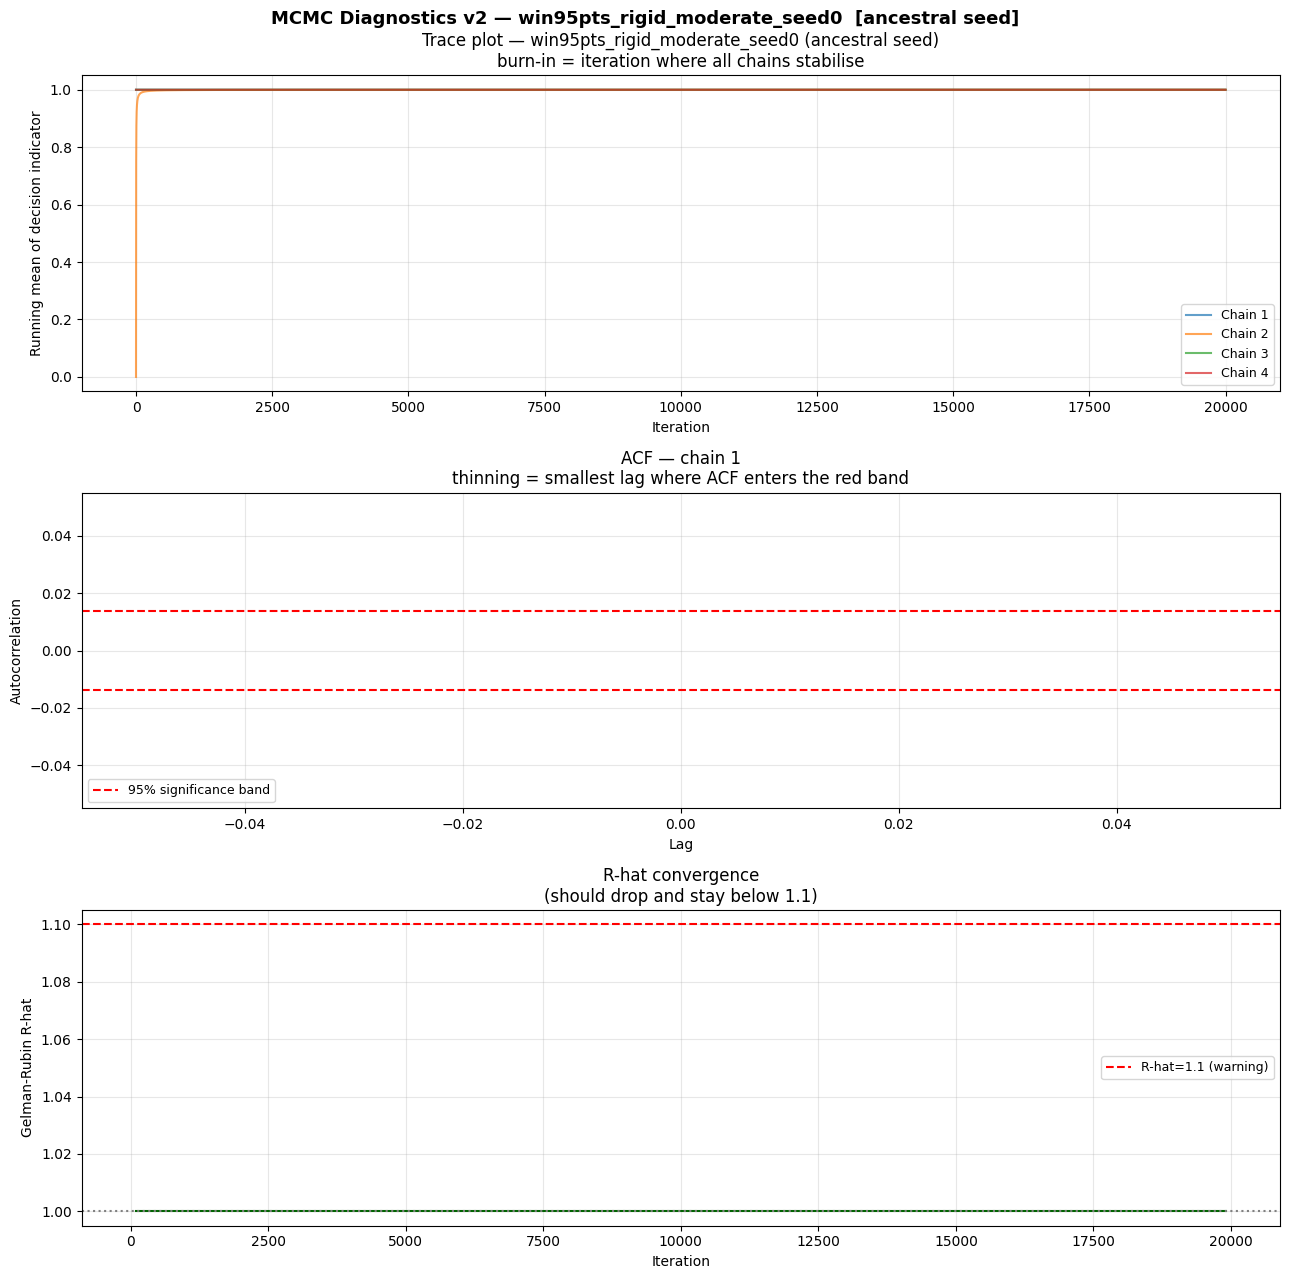


Network      : win95pts_rigid_moderate_seed0
Seed         : ancestral seed
Hidden vars  : 37
Suggested burn-in  : 19
Suggested thinning : 1000
Final R-hat        : 1.0000  ✓ converged

Δ_final=0.000  R-hat=1.000  ✓ ok

Regime 5/11: uniform
  α=1.0, β=1.0 — Uniform: all CPD values equally likely
  Seed 1/1 …   Chain 1/4...
CURRENT LOG P 
-59.23757572179336
  Chain 2/4...
CURRENT LOG P 
-60.27129043503981
  Chain 3/4...
CURRENT LOG P 
-63.479914491916965
  Chain 4/4...
CURRENT LOG P 
-57.98208796065192


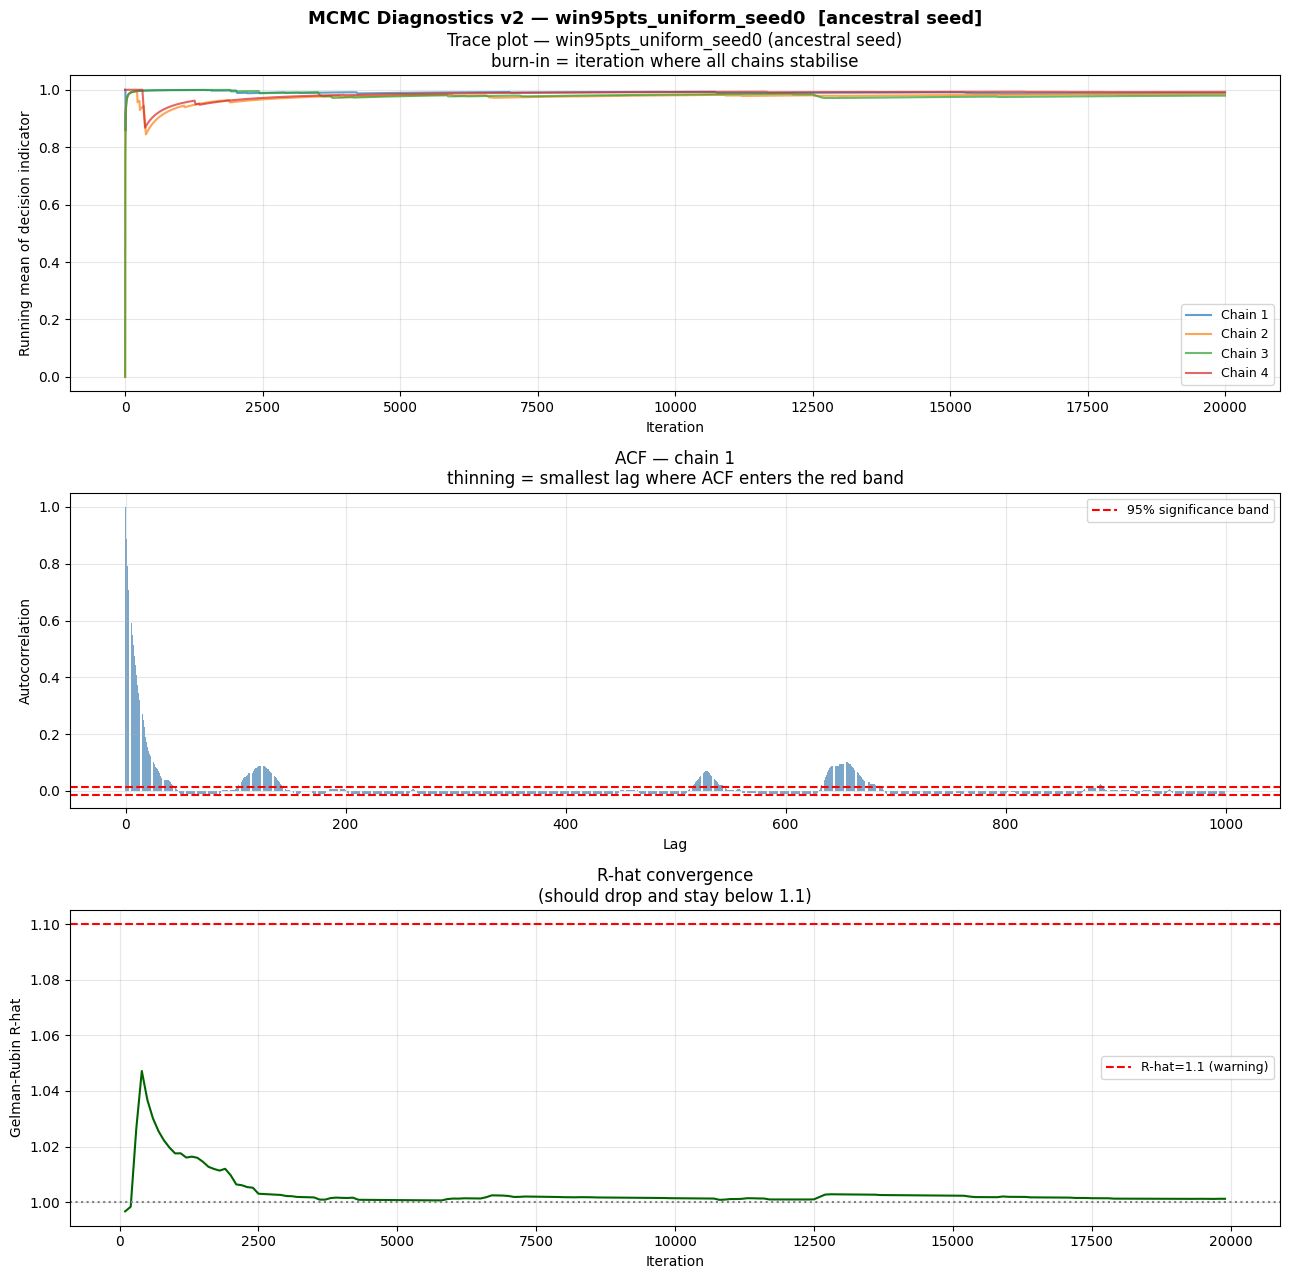


Network      : win95pts_uniform_seed0
Seed         : ancestral seed
Hidden vars  : 37
Suggested burn-in  : 16
Suggested thinning : 45
Final R-hat        : 1.0012  ✓ converged

Δ_final=0.013  R-hat=1.001  ✓ ok

Regime 6/11: uncertain_moderate
  α=3.0, β=3.0 — Bell-shaped: CPDs concentrated near 0.5
  Seed 1/1 …   Chain 1/4...
CURRENT LOG P 
-51.45663204427865
  Chain 2/4...
CURRENT LOG P 
-50.217165207630465
  Chain 3/4...
CURRENT LOG P 
-52.09515723547967
  Chain 4/4...
CURRENT LOG P 
-53.032634290288264


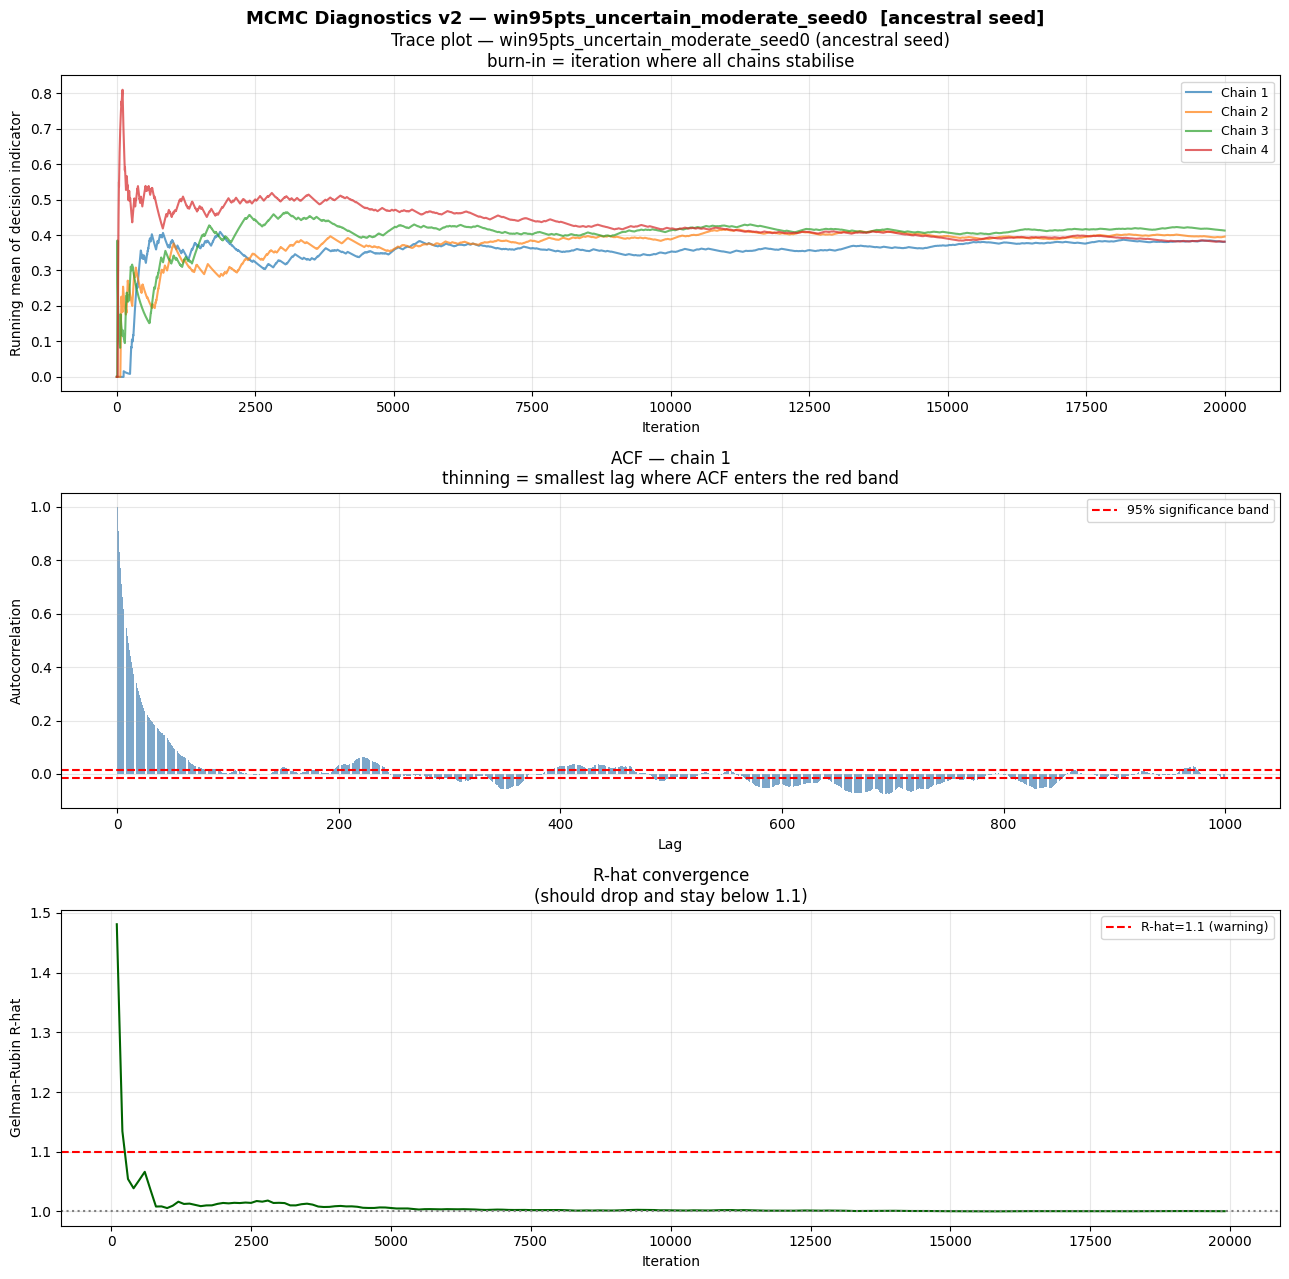


Network      : win95pts_uncertain_moderate_seed0
Seed         : ancestral seed
Hidden vars  : 37
Suggested burn-in  : 8134
Suggested thinning : 93
Final R-hat        : 1.0005  ✓ converged

Δ_final=0.032  R-hat=1.000  ✓ ok

Regime 7/11: uncertain_strong
  α=10.0, β=10.0 — Tightly concentrated near 0.5
  Seed 1/1 …   Chain 1/4...
CURRENT LOG P 
-50.374371127783306
  Chain 2/4...
CURRENT LOG P 
-49.87473611874137
  Chain 3/4...
CURRENT LOG P 
-51.56501369148955
  Chain 4/4...
CURRENT LOG P 
-50.51510357916763


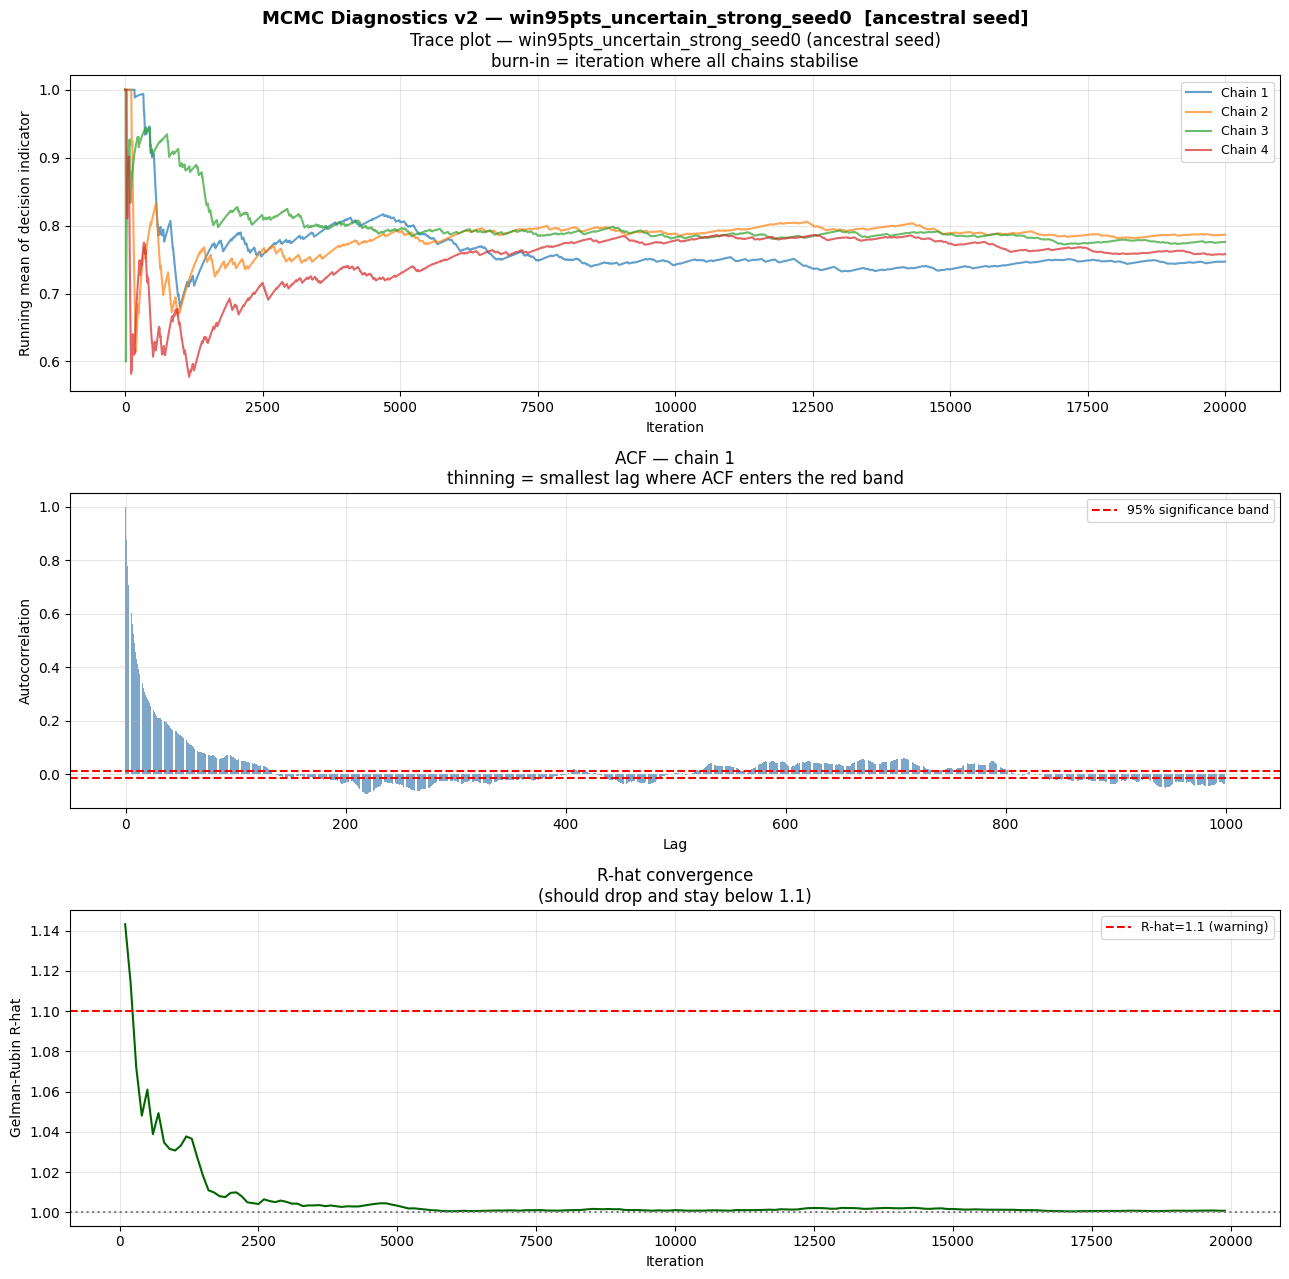


Network      : win95pts_uncertain_strong_seed0
Seed         : ancestral seed
Hidden vars  : 37
Suggested burn-in  : 2421
Suggested thinning : 133
Final R-hat        : 1.0009  ✓ converged

Δ_final=0.039  R-hat=1.001  ✓ ok

Regime 8/11: spread_bias_low
  α=0.5, β=2.0 — Spread + biased low: mean(p) ≈ 0.20, some variance
  Seed 1/1 …   Chain 1/4...
CURRENT LOG P 
-53.6768200025801
  Chain 2/4...
CURRENT LOG P 
-49.55944184561147
  Chain 3/4...
CURRENT LOG P 
-57.78317477938306
  Chain 4/4...
CURRENT LOG P 
-47.1345866338212


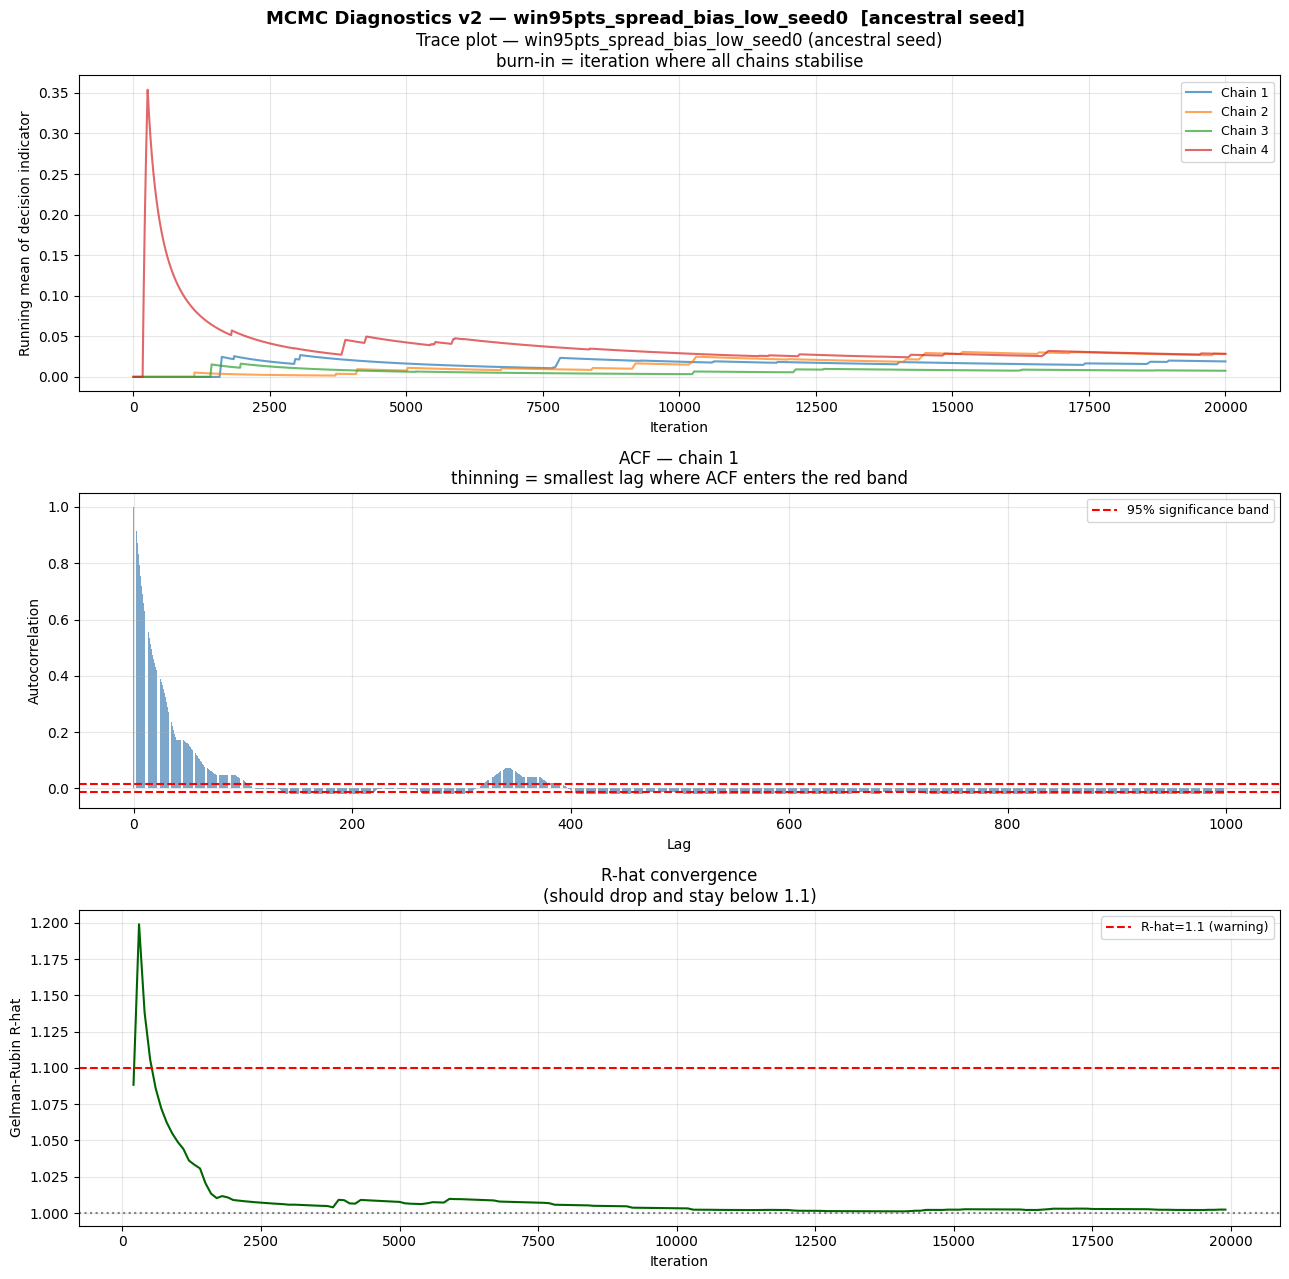


Network      : win95pts_spread_bias_low_seed0
Seed         : ancestral seed
Hidden vars  : 37
Suggested burn-in  : 0
Suggested thinning : 106
Final R-hat        : 1.0024  ✓ converged

Δ_final=0.021  R-hat=1.002  ✓ ok

Regime 9/11: concentrated_bias_low
  α=1.0, β=5.0 — Concentrated near 0: mean(p) ≈ 0.17, low variance
  Seed 1/1 …   Chain 1/4...
CURRENT LOG P 
-54.592827075879974
  Chain 2/4...
CURRENT LOG P 
-46.34579935954308
  Chain 3/4...
CURRENT LOG P 
-51.68119467853139
  Chain 4/4...
CURRENT LOG P 
-48.787120948495435


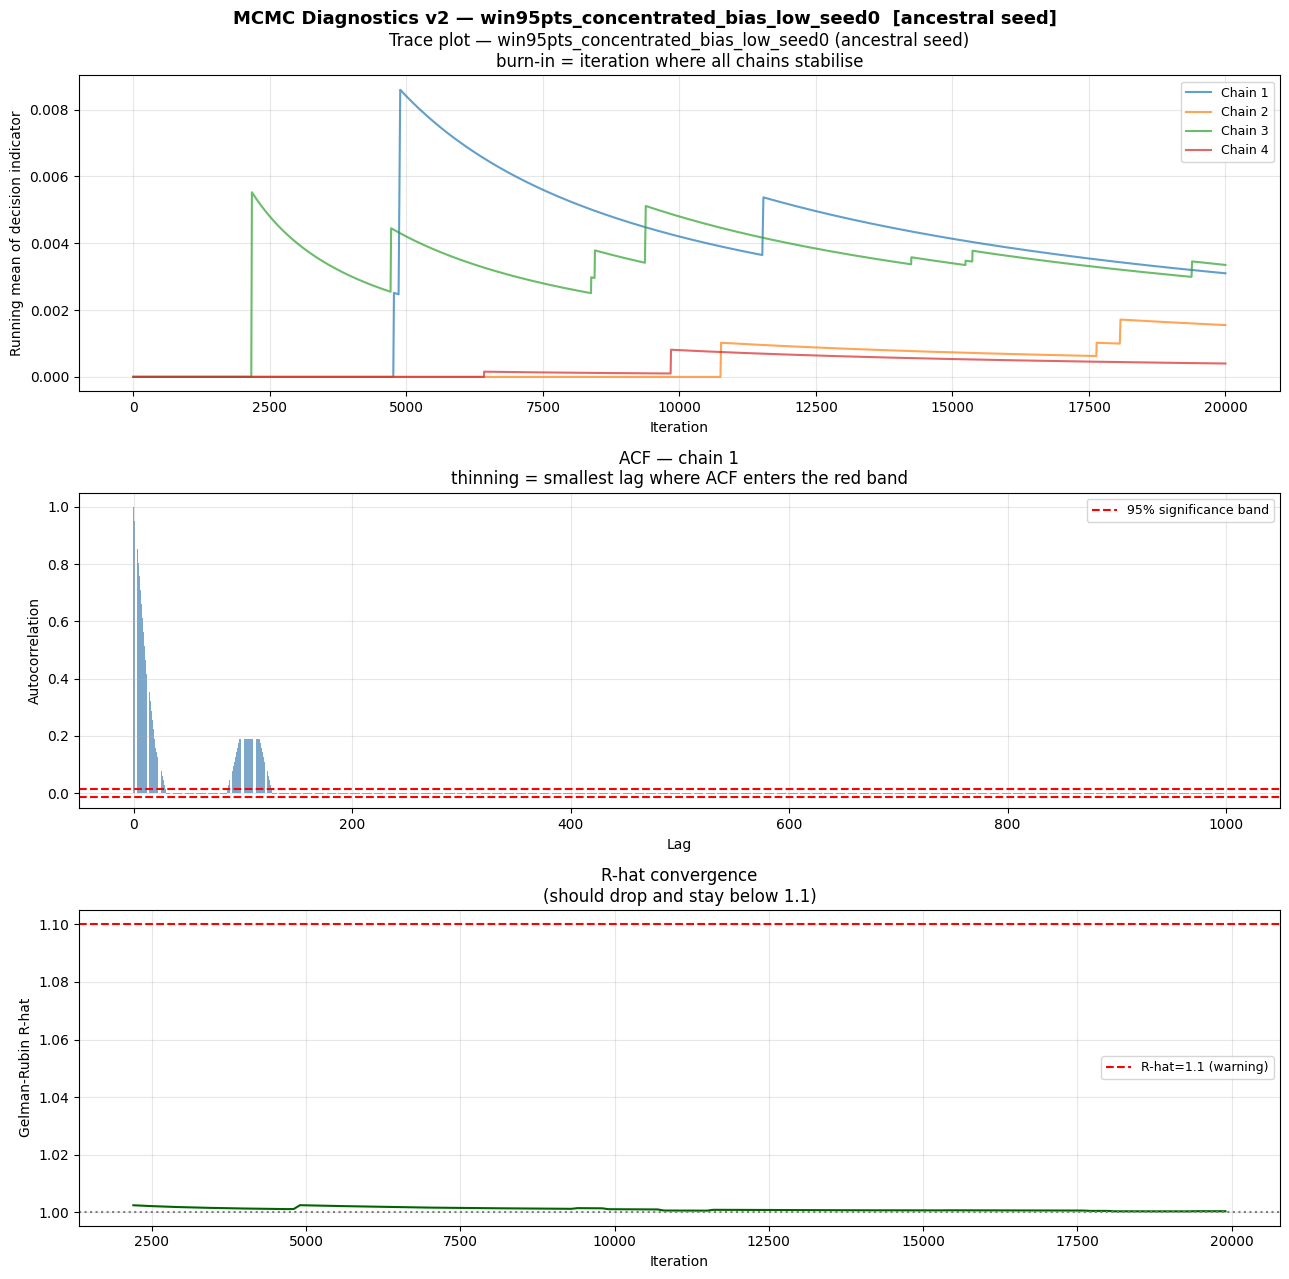


Network      : win95pts_concentrated_bias_low_seed0
Seed         : ancestral seed
Hidden vars  : 37
Suggested burn-in  : 0
Suggested thinning : 29
Final R-hat        : 1.0004  ✓ converged

Δ_final=0.003  R-hat=1.000  ✓ ok

Regime 10/11: spread_bias_high
  α=2.0, β=0.5 — Spread + biased high: mean(p) ≈ 0.80, some variance
  Seed 1/1 …   Chain 1/4...
CURRENT LOG P 
-81.25863058007583


In [ ]:
win95pts_model = get_example_model('win95pts')
target         = select_optimal_target_node(win95pts_model)
target_states  = win95pts_model.get_cpds(target).state_names[target]
target_value   = target_states[1]

interesting_patient = {
    'TTOK': 'No', 'NtSpd': 'OK', 'PgOrnttnOK': 'Incorrect', 'NetOK': 'Yes',
    'TrTypFnts': 'No', 'PrtPath': 'Correct', 'PrtPaper': 'No_Paper',
    'Problem1': 'No_Output', 'AppData': 'Correct', 'PrtDataOut': 'Yes',
    'PSERRMEM': 'Low_Memory', 'Problem4': 'Yes', 'FntInstlltn': 'Verified',
    'NnTTOK': 'No', 'AppDtGnTm': 'Fast_Enough',
    'DskLocal': 'Greater_than_2_Mb', 'PrtSel': 'Yes', 'Problem5': 'No',
    'IncmpltPS': 'Yes', 'PrtIcon': 'Normal', 'GDIIN': 'Yes',
    'PrtData': 'Yes', 'PrtPScript': 'Yes',
    'HrglssDrtnAftrPrnt': 'Fast_Enough', 'AvlblVrtlMmry': 'Adequate____1Mb_',
    'PrtPort': 'Yes', 'GrbldOtpt': 'No', 'GDIOUT': 'Yes',
    'TnrSpply': 'Adequate', 'PrntrAccptsTrtyp': 'No', 'PrtOn': 'No',
    'Problem6': 'No', 'PrtSpool': 'Disabled',
    'TstpsTxt': 'x_1_Mb_Available_VM', 'PrtTimeOut': 'Long_Enough',
    'PrntPrcssTm': 'Too_Long', 'PrtStatToner': 'Low__None', 'DrvSet': 'Correct',
}

# Add original CPDs as regime 0 for baseline comparison
CPD_PARAMS_WITH_ORIGINAL = [
    CPDParam(0.0, 0.0, 'original', 'Original Win95pts CPDs (unchanged)'),
] + CPD_PARAMS

# Temporarily patch CPD_PARAMS so the experiment loop uses the extended list
import builtins
_orig = CPD_PARAMS[:]
CPD_PARAMS.clear()
CPD_PARAMS.extend(CPD_PARAMS_WITH_ORIGINAL)

df = run_cpt_bimodality_experiment(
    interesting_patient=interesting_patient,
    target=target,
    target_value=target_value,
    threshold=0.5,
    n_iterations=20_000,
    n_chains=8,
    n_seeds=1,
    output_dir="cpt_bimodality_results",
    use_lw_seed=True,
)

CPD_PARAMS.clear()
CPD_PARAMS.extend(_orig)

In [ ]:
cpd = win95pts_model.get_cpds('PrtOn')
print(type(cpd.state_names), cpd.state_names)

<class 'dict'> {'PrtOn': ['Yes', 'No']}
